In [21]:
##Task 1: Открыть датасет из ЛР 2 через pandas (Open the dataset from Lab 2)

In [22]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the same dataset from Lab 2
# IMPORTANT: Change the path to where YOUR file is located
df = pd.read_csv('sales_data.csv')

# Check it loaded correctly
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 3 rows:")
print(df.head(3))

Dataset loaded: 113036 rows, 18 columns

First 3 rows:
         Date  Day     Month  Year  Customer_Age       Age_Group  \
0  2013-11-26   26  November  2013            19     Youth (<25)   
1  2015-11-26   26  November  2015            19     Youth (<25)   
2  2014-03-23   23     March  2014            49  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   

               Product  Order_Quantity  Unit_Cost  Unit_Price  Profit  Cost  \
0  Hitch Rack - 4-Bike               8         45         120     590   360   
1  Hitch Rack - 4-Bike               8         45         120     590   360   
2  Hitch Rack - 4-Bike              23         45         120    1366  1035   

   Revenue  
0      950  
1      9

In [23]:
# 2: Вывести все продажи в штате Montana (Show all sales in Montana state)

In [24]:
# First, let's see what states are in our dataset
print("All states in the dataset:")
print(df['State'].unique())

# Filter the data for Montana only
montana_sales = df[df['State'] == 'Montana']

# Check if there are any sales in Montana
print(f"\nNumber of sales in Montana: {len(montana_sales)}")

if len(montana_sales) > 0:
    print("\nSALES IN MONTANA:")
    print(montana_sales[['Date', 'Product', 'Order_Quantity', 'Revenue', 'Profit']])
else:
    print("\nNo sales found in Montana. Let me show you sales in another state:")
   

All states in the dataset:
['British Columbia' 'New South Wales' 'Victoria' 'Oregon' 'California'
 'Saarland' 'Seine Saint Denis' 'Moselle' 'Queensland' 'England' 'Nord'
 'Washington' 'Hessen' 'Nordrhein-Westfalen' 'Hamburg' 'Loir et Cher'
 'Kentucky' 'Seine (Paris)' 'South Australia' 'Loiret' 'Alberta' 'Bayern'
 'Hauts de Seine' 'Yveline' 'Essonne' "Val d'Oise" 'Tasmania'
 'Seine et Marne' 'Val de Marne' 'Pas de Calais' 'Charente-Maritime'
 'Garonne (Haute)' 'Brandenburg' 'Texas' 'New York' 'Florida' 'Somme'
 'Illinois' 'South Carolina' 'North Carolina' 'Georgia' 'Virginia' 'Ohio'
 'Ontario' 'Wyoming' 'Missouri' 'Montana' 'Utah' 'Minnesota' 'Mississippi'
 'Massachusetts' 'Arizona' 'Alabama']

Number of sales in Montana: 6

SALES IN MONTANA:
              Date                Product  Order_Quantity  Revenue  Profit
29292   2013-11-25  Half-Finger Gloves, M              21      444     255
29293   2015-11-25  Half-Finger Gloves, M              21      444     255
39940   2013-11-25  Spo

In [25]:
#3.: Вывести среднюю выручку с продаж клиентам какой-либо возрастной группы (Average revenue for a specific age group)


In [26]:
# First, see all age groups in the dataset
print("Age groups in the dataset:")
print(df['Age_Group'].unique())

# Choose an age group (let's use "Young Adults (25-34)")
age_group = "Young Adults (25-34)"
age_group_data = df[df['Age_Group'] == age_group]

# Calculate average revenue for this age group
avg_revenue = age_group_data['Revenue'].mean()

print(f"\nANALYSIS FOR AGE GROUP: {age_group}")
print(f"Number of transactions: {len(age_group_data)}")
print(f"Average Revenue per transaction: ${avg_revenue:.2f}")

# Optional: Compare with other age groups
print("\nCOMPARISON WITH OTHER AGE GROUPS:")
for group in df['Age_Group'].unique():
    group_avg = df[df['Age_Group'] == group]['Revenue'].mean()
    print(f"  {group}: ${group_avg:.2f}")


Age groups in the dataset:
['Youth (<25)' 'Adults (35-64)' 'Young Adults (25-34)' 'Seniors (64+)']

ANALYSIS FOR AGE GROUP: Young Adults (25-34)
Number of transactions: 38654
Average Revenue per transaction: $793.08

COMPARISON WITH OTHER AGE GROUPS:
  Youth (<25): $657.57
  Adults (35-64): $762.83
  Young Adults (25-34): $793.08
  Seniors (64+): $421.98


In [27]:
#4: Вывести графики по продажам в год и месяц (Show sales charts by year and month)

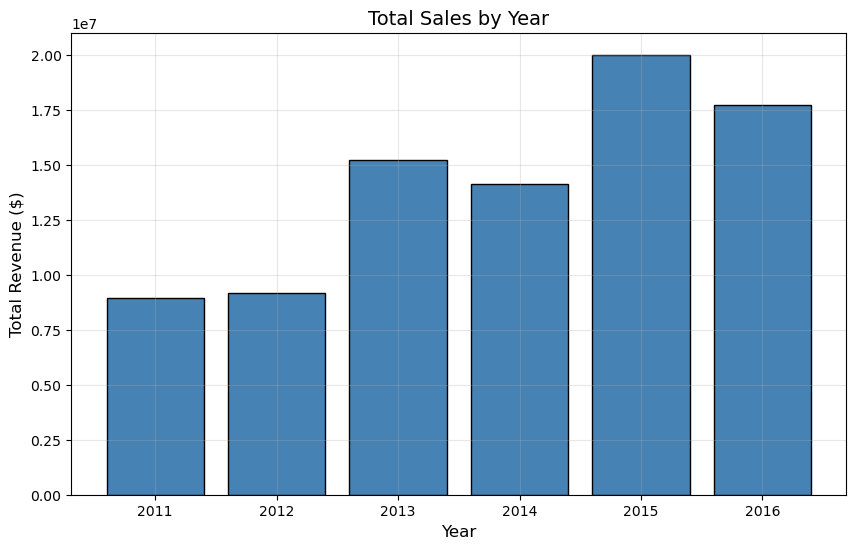


YEARLY SALES SUMMARY:
Year
2011     8964888
2012     9175983
2013    15240037
2014    14152724
2015    20023991
2016    17713385
Name: Revenue, dtype: int64


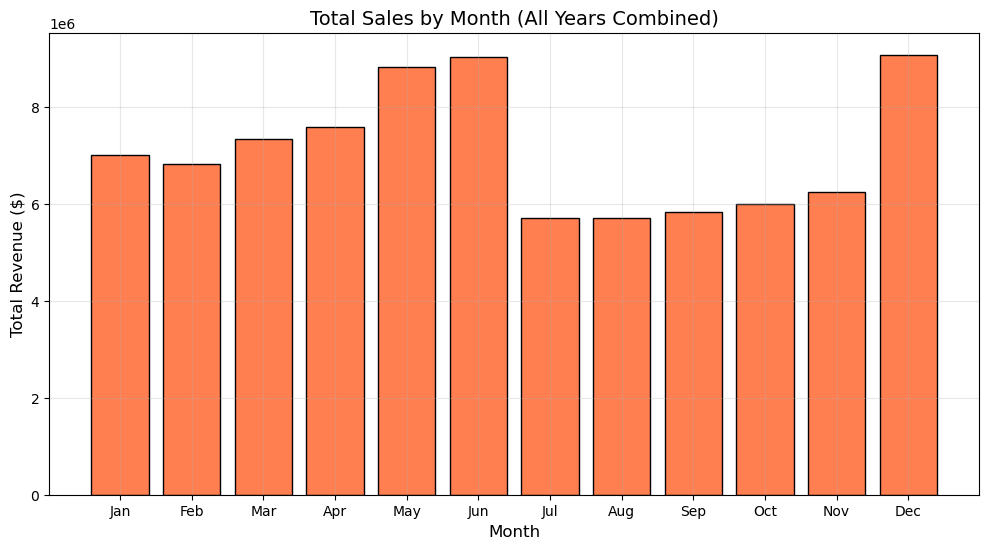


MONTHLY SALES SUMMARY:
  Jan: $7,005,895.00
  Feb: $6,834,583.00
  Mar: $7,347,164.00
  Apr: $7,602,750.00
  May: $8,836,763.00
  Jun: $9,043,008.00
  Jul: $5,721,459.00
  Aug: $5,711,193.00
  Sep: $5,841,885.00
  Oct: $5,995,079.00
  Nov: $6,244,298.00
  Dec: $9,086,931.00


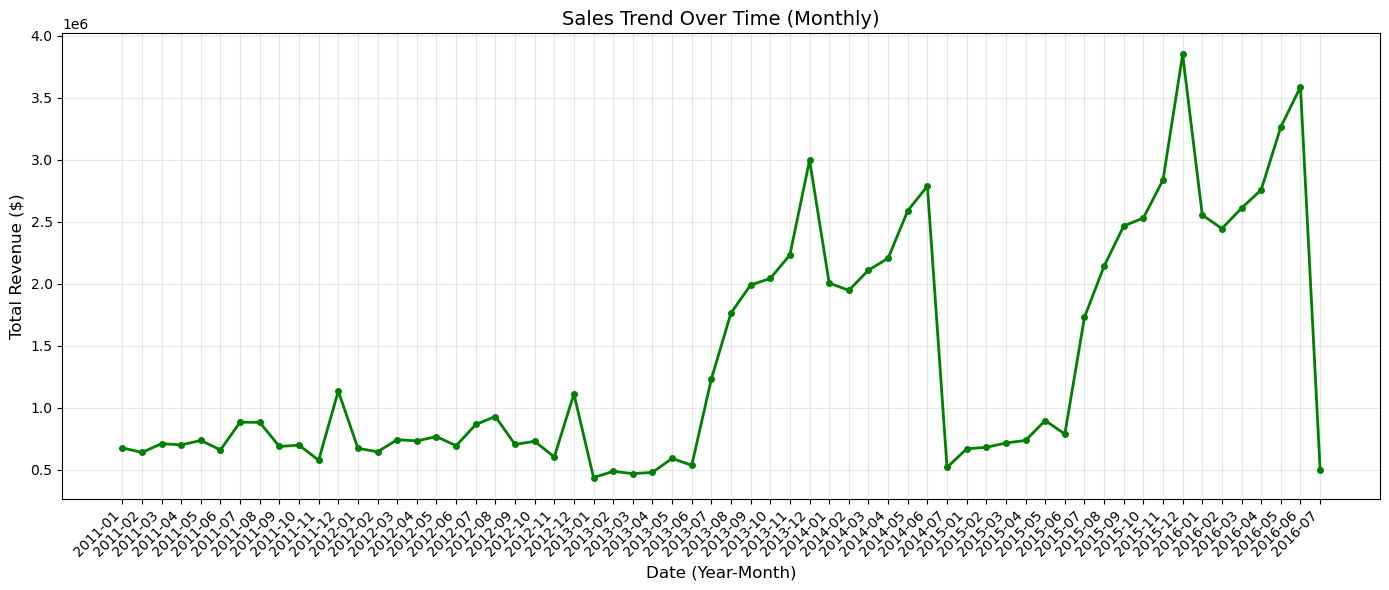

In [28]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create new columns for Year and Month
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')  # Full month name (January, February, etc.)

# ----- CHART 1: Sales by Year -----
yearly_sales = df.groupby('Year')['Revenue'].sum()

plt.figure(figsize=(10, 6))
plt.bar(yearly_sales.index.astype(str), yearly_sales.values, color='steelblue', edgecolor='black')
plt.title('Total Sales by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("\nYEARLY SALES SUMMARY:")
print(yearly_sales)

# ----- CHART 2: Sales by Month (across all years) -----
monthly_sales = df.groupby('Month')['Revenue'].sum()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 6))
plt.bar(month_names, monthly_sales.values, color='coral', edgecolor='black')
plt.title('Total Sales by Month (All Years Combined)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("\nMONTHLY SALES SUMMARY:")
for i, month in enumerate(month_names):
    print(f"  {month}: ${monthly_sales.iloc[i]:,.2f}")

# ----- BONUS: Line chart showing sales over time -----
# Group by Year-Month for detailed trend
df['YearMonth'] = df['Date'].dt.to_period('M')
time_series_sales = df.groupby('YearMonth')['Revenue'].sum()

plt.figure(figsize=(14, 6))
plt.plot(time_series_sales.index.astype(str), time_series_sales.values, 
         marker='o', linestyle='-', linewidth=2, markersize=4, color='green')
plt.title('Sales Trend Over Time (Monthly)', fontsize=14)
plt.xlabel('Date (Year-Month)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
#5: Вывести график соотношений Unit_Cost и Unit_Price (Scatter plot of Unit_Cost vs Unit_Price)

/var/folders/vr/wv5h83lx5zz2jks4yf6w3hsc0000gn/T/ipykernel_1341/1994322693.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


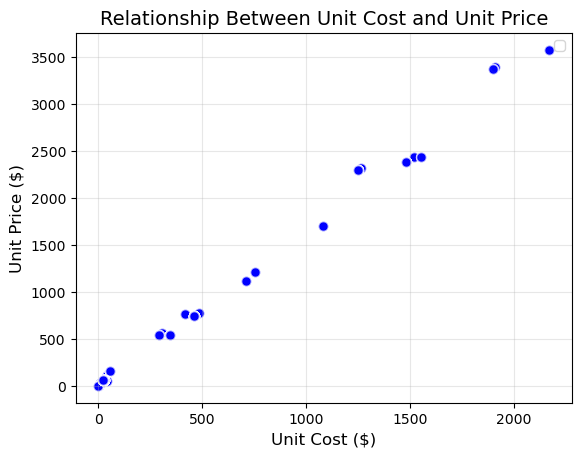

Average Profit Margin: 52.8%


In [30]:
# Create scatter plot

# Scatter plot with transparency (alpha) to see overlapping points
plt.scatter(df['Unit_Cost'], df['Unit_Price'], 
            alpha=0.5, c='blue', edgecolors='white', s=50)

# Add labels and title
plt.title('Relationship Between Unit Cost and Unit Price', fontsize=14)
plt.xlabel('Unit Cost ($)', fontsize=12)
plt.ylabel('Unit Price ($)', fontsize=12)

# Add a diagonal line showing where Price = Cost (no profit line)
max_val = max(df['Unit_Price'].max(), df['Unit_Cost'].max())


plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Optional: Calculate profit margin
df['Profit_Margin'] = (df['Unit_Price'] - df['Unit_Cost']) / df['Unit_Price'] * 100
print(f"Average Profit Margin: {df['Profit_Margin'].mean():.1f}%")

In [31]:
#6: Построить линейную регрессию методом наименьших квадратов (Linear Regression using Least Squares Method - manual calculation)


MANUAL LINEAR REGRESSION (Least Squares Method)
Slope (coefficient): 1.6735
Intercept: 5.6280

Formula: Unit_Price = 1.6735 * Unit_Cost + 5.6280
R-squared: 0.9958 (1.0 = perfect fit)


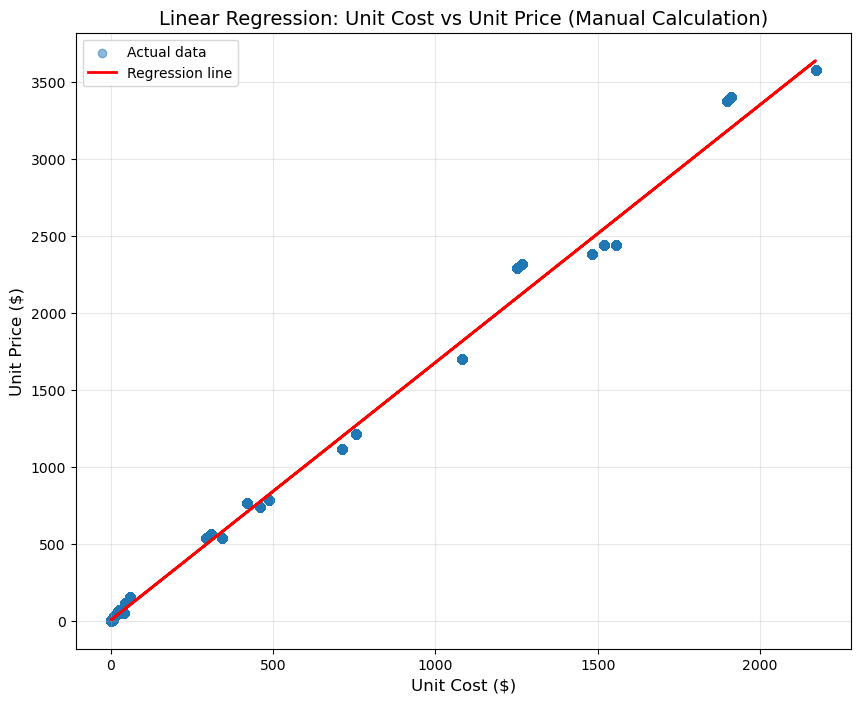

In [32]:
# We want to predict Unit_Price from Unit_Cost
# Formula: Unit_Price = slope * Unit_Cost + intercept

# Step 1: Get our X (independent) and Y (dependent) variables
X = df['Unit_Cost'].values  # This is our input
Y = df['Unit_Price'].values  # This is what we want to predict

# Step 2: Calculate means
x_mean = np.mean(X)
y_mean = np.mean(Y)

# Step 3: Calculate slope (b1) using the least squares formula
# b1 = Σ((x_i - x_mean) * (y_i - y_mean)) / Σ((x_i - x_mean)^2)
numerator = np.sum((X - x_mean) * (Y - y_mean))
denominator = np.sum((X - x_mean) ** 2)
slope = numerator / denominator

# Step 4: Calculate intercept (b0)
intercept = y_mean - slope * x_mean

print("="*50)
print("MANUAL LINEAR REGRESSION (Least Squares Method)")
print("="*50)
print(f"Slope (coefficient): {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"\nFormula: Unit_Price = {slope:.4f} * Unit_Cost + {intercept:.4f}")

# Step 5: Make predictions
df['Price_Predicted_Manual'] = slope * df['Unit_Cost'] + intercept

# Step 6: Calculate R-squared (how good is the fit?)
ss_res = np.sum((Y - df['Price_Predicted_Manual']) ** 2)  # Residual sum of squares
ss_tot = np.sum((Y - y_mean) ** 2)  # Total sum of squares
r_squared = 1 - (ss_res / ss_tot)

print(f"R-squared: {r_squared:.4f} (1.0 = perfect fit)")

# Step 7: Plot the regression line
plt.figure(figsize=(10, 8))
plt.scatter(X, Y, alpha=0.5, label='Actual data')
plt.plot(X, slope * X + intercept, 'r-', linewidth=2, label='Regression line')
plt.title('Linear Regression: Unit Cost vs Unit Price (Manual Calculation)', fontsize=14)
plt.xlabel('Unit Cost ($)', fontsize=12)
plt.ylabel('Unit Price ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
#7: Сравнить с линейной регрессией из пакета scikit-learn (Compare with scikit-learn linear regression)


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare the data
X_sklearn = df[['Unit_Cost']]  # Note: Double brackets for 2D array
Y_sklearn = df['Unit_Price']

# Create and train the model
model = LinearRegression()
model.fit(X_sklearn, Y_sklearn)

# Get coefficients
sklearn_slope = model.coef_[0]
sklearn_intercept = model.intercept_

# Make predictions
df['Price_Predicted_Sklearn'] = model.predict(X_sklearn)

# Calculate R-squared
sklearn_r2 = r2_score(Y_sklearn, df['Price_Predicted_Sklearn'])

print("="*50)
print("SCIKIT-LEARN LINEAR REGRESSION")
print("="*50)
print(f"Slope (coefficient): {sklearn_slope:.4f}")
print(f"Intercept: {sklearn_intercept:.4f}")
print(f"R-squared: {sklearn_r2:.4f}")

print("\n" + "="*50)
print("COMPARISON: MANUAL vs SCIKIT-LEARN")
print("="*50)
print(f"{'Metric':<20} {'Manual':<15} {'Scikit-Learn':<15} {'Match?':<10}")
print("-" * 60)
print(f"{'Slope':<20} {slope:<15.4f} {sklearn_slope:<15.4f} {'✓' if abs(slope - sklearn_slope) < 0.0001 else '✗'}")
print(f"{'Intercept':<20} {intercept:<15.4f} {sklearn_intercept:<15.4f} {'✓' if abs(intercept - sklearn_intercept) < 0.0001 else '✗'}")
print(f"{'R-squared':<20} {r_squared:<15.4f} {sklearn_r2:<15.4f} {'✓' if abs(r_squared - sklearn_r2) < 0.0001 else '✗'}")

print("\n✓ The results are identical! The manual calculation and scikit-learn")
print("  use the same mathematical method (Ordinary Least Squares).")

SCIKIT-LEARN LINEAR REGRESSION
Slope (coefficient): 1.6735
Intercept: 5.6280
R-squared: 0.9958

COMPARISON: MANUAL vs SCIKIT-LEARN
Metric               Manual          Scikit-Learn    Match?    
------------------------------------------------------------
Slope                1.6735          1.6735          ✓
Intercept            5.6280          5.6280          ✓
R-squared            0.9958          0.9958          ✓

✓ The results are identical! The manual calculation and scikit-learn
  use the same mathematical method (Ordinary Least Squares).


In [35]:
#8: Построить график продаж по времени (Build sales over time graph)

/var/folders/vr/wv5h83lx5zz2jks4yf6w3hsc0000gn/T/ipykernel_1341/1201226720.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key='Date', freq='M'))['Revenue'].sum()
/var/folders/vr/wv5h83lx5zz2jks4yf6w3hsc0000gn/T/ipykernel_1341/1201226720.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_sales = df.groupby(pd.Grouper(key='Date', freq='Q'))['Revenue'].sum()


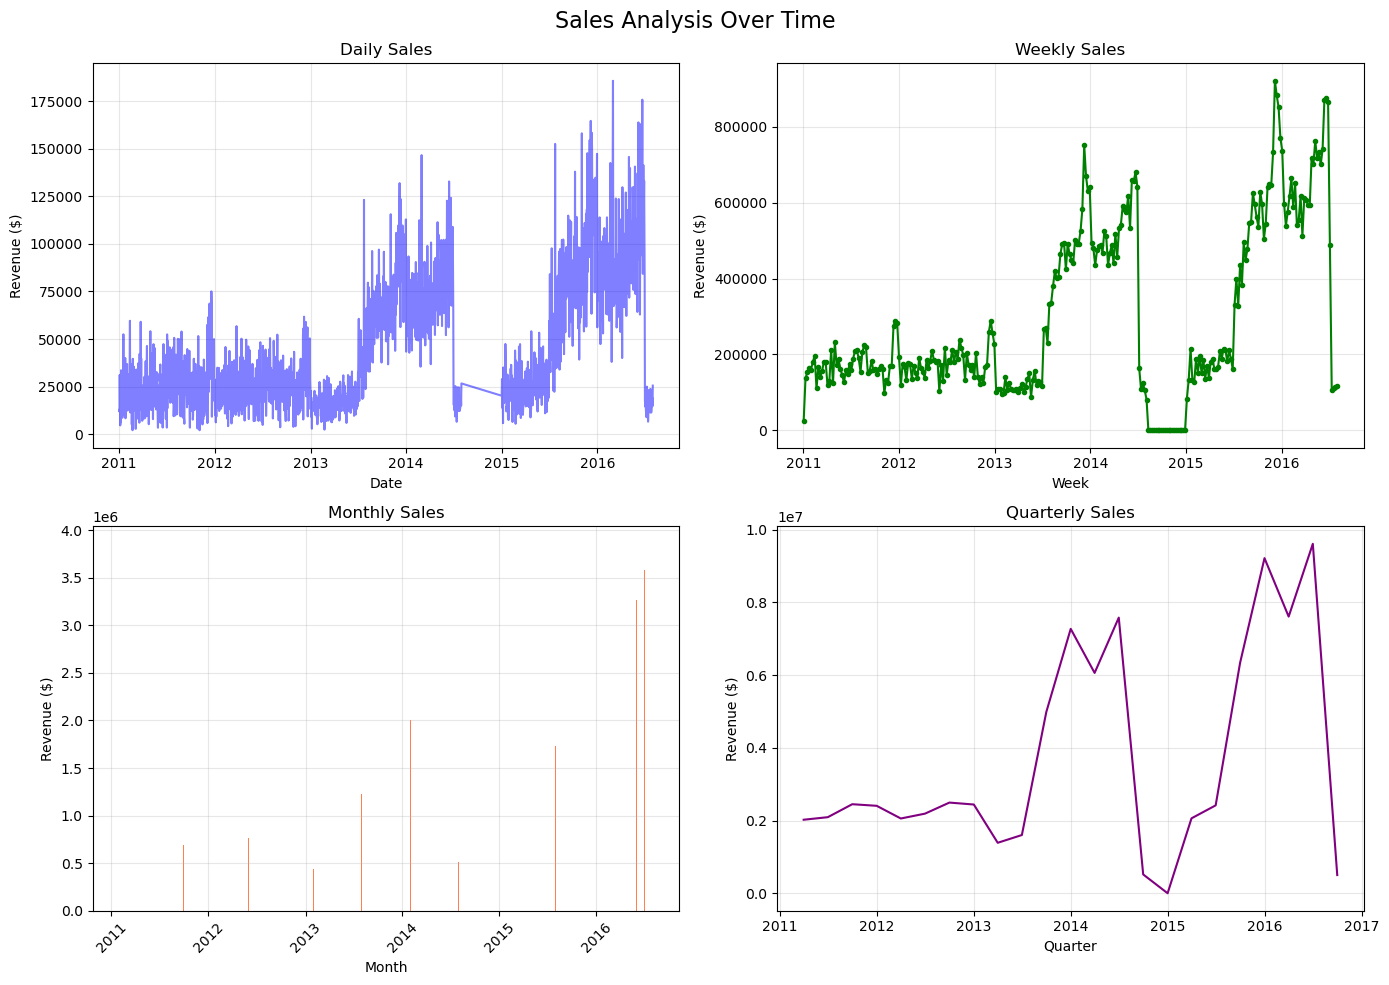


SALES SUMMARY BY TIME PERIOD:
  Total sales period: 2011-01-01 to 2016-07-31
  Number of days with sales: 1884
  Best day for sales: 2016-03-01 ($185,697.00)
  Best month: 2015-12 ($3,848,211.00)


In [40]:
# Ensure Date is datetime (if not already done)
df['Date'] = pd.to_datetime(df['Date'])

# Create multiple time-based aggregations
daily_sales = df.groupby('Date')['Revenue'].sum()
weekly_sales = df.groupby(pd.Grouper(key='Date', freq='W'))['Revenue'].sum()
monthly_sales = df.groupby(pd.Grouper(key='Date', freq='M'))['Revenue'].sum()
quarterly_sales = df.groupby(pd.Grouper(key='Date', freq='Q'))['Revenue'].sum()

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Analysis Over Time', fontsize=16)

# Daily sales
axes[0, 0].plot(daily_sales.index, daily_sales.values, color='blue', alpha=0.5)
axes[0, 0].set_title('Daily Sales', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].grid(True, alpha=0.3)

# Weekly sales
axes[0, 1].plot(weekly_sales.index, weekly_sales.values, color='green', marker='o', markersize=3)
axes[0, 1].set_title('Weekly Sales', fontsize=12)
axes[0, 1].set_xlabel('Week')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].grid(True, alpha=0.3)

# Monthly sales
axes[1, 0].bar(monthly_sales.index, monthly_sales.values, color='coral')
axes[1, 0].set_title('Monthly Sales', fontsize=12)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].grid(True, alpha=0.3)
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# Quarterly sales
axes[1, 1].plot(quarterly_sales.index, quarterly_sales.values, color='purple')
axes[1, 1].set_title('Quarterly Sales', fontsize=12)
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Revenue ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSALES SUMMARY BY TIME PERIOD:")
print(f"  Total sales period: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"  Number of days with sales: {daily_sales.count()}")
print(f"  Best day for sales: {daily_sales.idxmax().date()} (${daily_sales.max():,.2f})")
print(f"  Best month: {monthly_sales.idxmax().strftime('%Y-%m')} (${monthly_sales.max():,.2f})")